### Random Forest Regressor

In [ ]:
# Random Forest Regressor is a supervised machine learning algorithm used for solving regression problems, where the target variable is continuous (for example, house prices, temperature prediction, sales forecasting).
# It is an ensemble learning technique that combines the predictions of multiple Decision Trees to produce a more accurate and robust result.

#### How Random Forest Regressor Works:

In [ ]:
# 1.Create multiple decision trees from different random subsets of the training data.
# 2.Each tree is trained independently.
# 3.At each split, only a random subset of features is considered.
# 4.For a new input, every tree predicts a value.
# 5.The final prediction is the average of all tree predictions.

### Formula


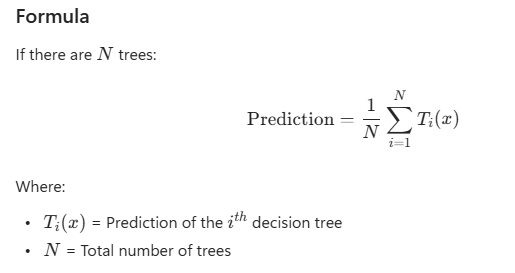

### Architecture

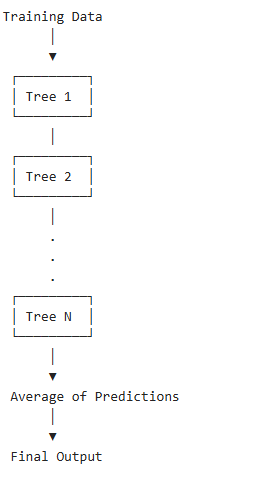

### Example

In [ ]:
# Suppose we want to predict the price of a house.
# Individual Tree Predictions

# Tree                  Predicted Price ($)
# Tree1                 250,000
# Tree2                 260,000
# Tree3                 255,000
# Tree4                 245,000


# Final Prediction:
#     250000+260000+255000+24500​/4 =252500
             
# Predicted House Price = $252,500

### Advantages
- ✅ High prediction accuracy
- ✅ Reduces overfitting compared to a single Decision Tree
- ✅ Handles large datasets effectively
- ✅ Works well with non-linear relationships
- ✅ Can estimate feature importance
- ✅ Robust against noise and outliers

### Disadvantages
- ❌ Training can be slower compared to a single Decision Tree
- ❌ Requires more memory
- ❌ Less interpretable than a single Decision Tree
- ❌ Large forests may increase computational cost

### Important Hyperparameters
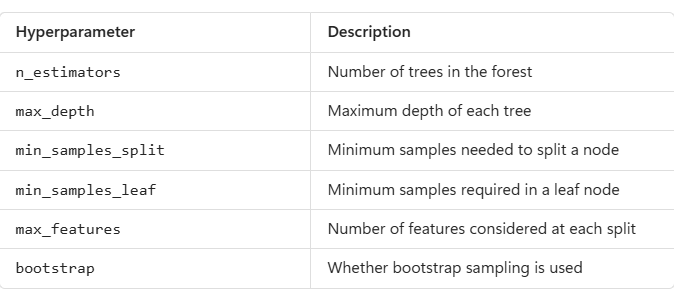

### Simple Example For RFR

In [14]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score


In [4]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9234000,16084,3,2,3,yes,no,yes,yes,yes,1,no,furnished
1,8963000,14858,4,4,4,yes,no,no,yes,no,1,no,furnished
2,8890000,15719,2,1,3,yes,yes,no,no,yes,1,no,furnished
3,8664000,15195,4,1,2,yes,yes,yes,no,yes,1,yes,semi-furnished
4,8620000,14790,3,3,2,yes,yes,yes,no,yes,0,no,furnished


In [5]:
print("Encode Categorical Variables:")
from sklearn.preprocessing import LabelEncoder

lr  = LabelEncoder()

df['mainroad'] = lr.fit_transform(df['mainroad'])
df['guestroom'] = lr.fit_transform(df['guestroom'])
df['basement'] = lr.fit_transform(df['basement'])
df['hotwaterheating'] = lr.fit_transform(df['hotwaterheating'])
df['airconditioning'] = lr.fit_transform(df['airconditioning'])
df['prefarea'] = lr.fit_transform(df['prefarea'])

#why im using the manual mapping for the furnishistatus is because it contain 3 furnished, semi-fur, un-fur 
#if we use label encoder it assign 0 1 2 to variable in alphabetical order so the un-fur - 2, semi-f-1 , fur -0 
# it will tricks our model into thinking that an unfurnished house (2) is "greater than" or worth more than a furnished house (0).
furnishing_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
df['furnishingstatus'] = df['furnishingstatus'].map(furnishing_map)
df


Encode Categorical Variables:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9234000,16084,3,2,3,1,0,1,1,1,1,0,2
1,8963000,14858,4,4,4,1,0,0,1,0,1,0,2
2,8890000,15719,2,1,3,1,1,0,0,1,1,0,2
3,8664000,15195,4,1,2,1,1,1,0,1,1,1,1
4,8620000,14790,3,3,2,1,1,1,0,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1939000,1951,2,1,1,0,0,0,0,0,1,0,1
996,1820000,1840,2,1,2,1,1,0,0,1,0,0,0
997,1750000,2378,1,1,1,1,0,0,0,0,3,0,0
998,1750000,3015,3,1,3,0,1,0,0,0,0,0,0


In [7]:
X = df.drop(['price'],axis=1)
y = df['price']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [12]:
y_pred = model.predict(X_test)
print('Predicted Price:',y_pred[:5])
print('Actual Price:',y_test[:5])

Predicted Price: [5562140. 4285160. 4534730. 5105190. 6141470.]
Actual Price: 521    5230000
737    4127000
740    4120000
660    4557000
411    5705000
Name: price, dtype: int64


In [15]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("Mse",mse)
print("R2 score",r2)

Mse 268813116544.5
R2 score 0.8862361905155054
